In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("tech_layoff_2026.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_") 
df.head(5)

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [3]:
for col in df.select_dtypes(include='object'):
    print(f"column : {col}")
    print(df[col].unique())
    print("\n")

column : company
['Amazon' 'Block' 'Meta Reality Labs' 'Atlassian' 'Oracle' 'Salesforce'
 'Autodesk' 'eBay' 'Pinterest' 'Ericsson' 'ASML' 'ams OSRAM' 'Ocado'
 'WiseTech Global' 'Cisco' 'T-Mobile' 'SK Battery America' 'Walgreens'
 'Telefonica' 'xAI' 'Palo Alto Networks' 'Livspace' 'General Motors Tech'
 'Workday' 'Ergo Insurance' 'Algoma Steel' 'Meta Platforms (Planned)']


column : layoff_date
['2026-01-15' '2026-02-28' '2026-01-20' '2026-03-14' '2026-02-01'
 '2026-01-10' '2026-01-25' '2026-01-28' '2026-02-10' '2026-02-05'
 '2026-01-30' '2026-02-20' '2026-02-15' '2026-02-02' '2026-03-16'
 '2026-03-11' '2026-02-25' '2026-02-18' '2026-01-22' '2026-03-01'
 '2026-03-07' '2026-03-13' '2026-03-23']


column : sector
['E-Commerce/Cloud' 'Fintech' 'Social Media/VR' 'Enterprise Software'
 'CRM/SaaS' 'Design Software' 'E-Commerce' 'Social Media'
 'Telecommunications' 'Semiconductors' 'Grocery Tech' 'Logistics Software'
 'Networking/Cybersecurity' 'EV Batteries' 'Retail Pharmacy' 'AI Research'
 '

In [4]:
print(f"null values : \n{df.isnull().sum()}")
print("================")
print(f"duplicate values : {df.duplicated().sum()}")

null values : 
company                          0
layoff_date                      0
jobs_cut                         0
pct_workforce_cut                0
sector                           0
country                          0
hq_city                          0
ai_cited                         0
reason_stated                    0
company_revenue_2025_bn          0
pre_layoff_headcount             0
stock_change_day_pct             0
simultaneous_ai_investment_bn    0
roles_most_affected              0
replacement_roles                0
ceo_quote                        0
layoffs_2024                     0
layoffs_2025                     0
verified_source                  0
month                            0
quarter                          0
region                           0
layoff_size_category             0
stock_reaction                   0
laid_off_vs_headcount_pct        0
data_as_of                       0
dtype: int64
duplicate values : 0


# Data analysis

1 . Are companies citing AI actually laying off more employees than others?

ai_cited
False    14
True     14
Name: count, dtype: int64


,total_layoff,avg_layoff
ai_cited,,
False,39121,2794.357143
True,62025,4430.357143


<Figure size 1000x700 with 0 Axes>

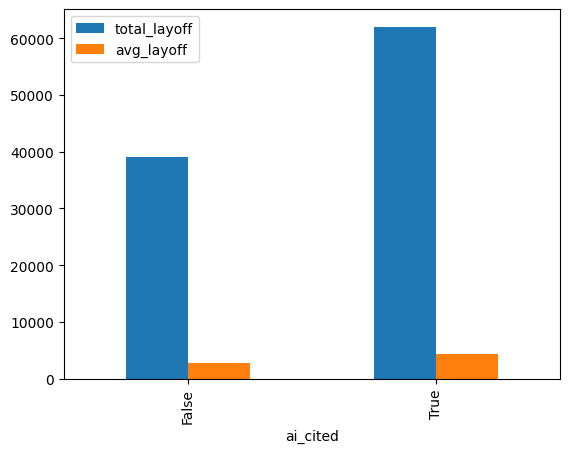

In [5]:
print(df['ai_cited'].value_counts())
avg_job_cut = df.groupby('ai_cited')[['jobs_cut','pct_workforce_cut']].agg(total_layoff=('jobs_cut' , 'sum'),
avg_layoff=('jobs_cut','mean'))
display(avg_job_cut)
print("=====================")
plt.figure(figsize=(10,7))
avg_job_cut.plot(kind='bar')
plt.show()

👆AI significantly laying off more employees than others

2 . Which industries are most vulnerable to layoffs in 2026?

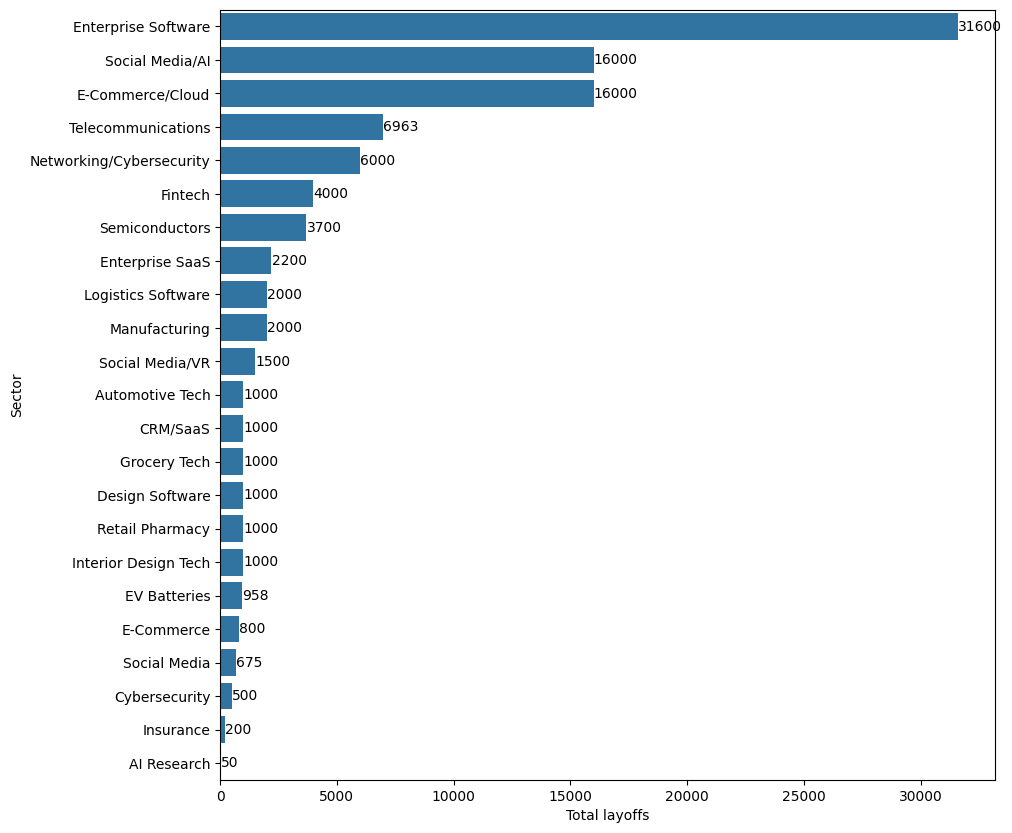

In [6]:
industry_layoff = df.groupby('sector').agg(total_layoff=('jobs_cut', 'sum'))
industry_layoff = industry_layoff.sort_values('total_layoff',ascending=False)  # optional: sort for nicer view

plt.figure(figsize=(10, 10))
ax = sns.barplot(
    x=industry_layoff['total_layoff'],   # numbers on X
    y=industry_layoff.index,            # sectors on Y
    orient='h'                          # explicitly horizontal (optional when y is categorical)
)

# add data labels at the end of bars
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 5,                 # x position just after bar end
                p.get_y() + p.get_height()/2,
                int(width),
                va='center')

plt.xlabel("Total layoffs")
plt.ylabel("Sector")
plt.show()

3 . Do larger companies lay off more aggressively or more conservatively?

In [21]:
bins = [0 , 10000 , 50000 , 200000 , float("inf")]
labels = ['small(<10k)' , 'Mid(10k-50k)','Large(50k-200k)','Very Large(>200k)']
df['emp_size'] = pd.cut(df["pre_layoff_headcount"], bins=bins, labels=labels)
aggressively_layoff = df.groupby('emp_size').agg(
    avg_workforce_cut = ('pct_workforce_cut' , 'mean'),
    total_layoff = ('jobs_cut' , 'sum')
)
aggressively_layoff


,avg_workforce_cut,total_layoff
emp_size,,
small(<10k),18.366667,10883
Mid(10k-50k),7.112500,10800
Large(50k-200k),8.055556,62463
Very Large(>200k),1.600000,17000


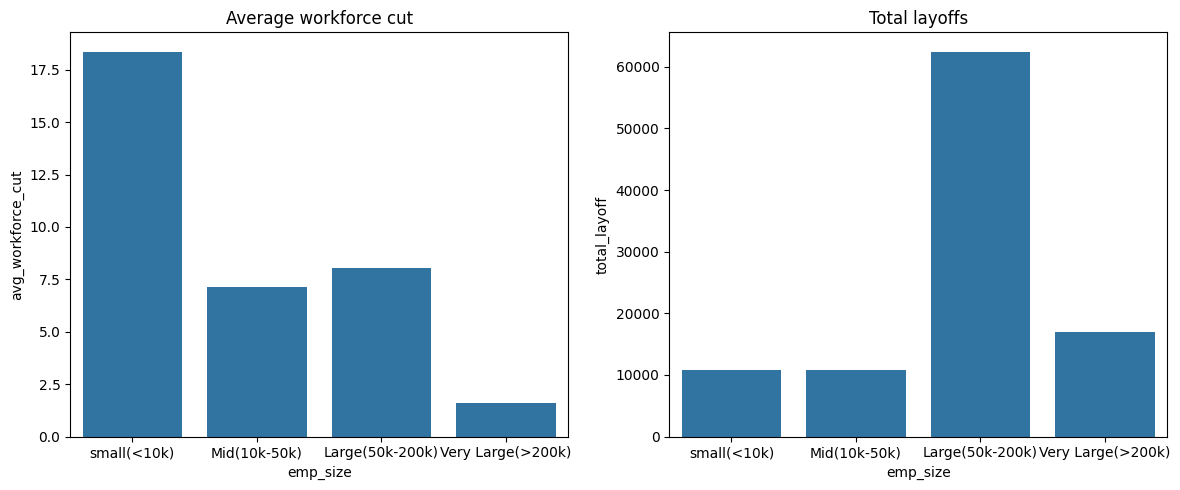

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

sns.barplot(
    data=aggressively_layoff,
    x='emp_size', y='avg_workforce_cut', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=aggressively_layoff,
    x='emp_size', y='total_layoff', ax=axes[1]
)
axes[1].set_title('Total layoffs')

plt.tight_layout()
plt.show()

4 . Do layoffs positively impact stock sentiment?

In [28]:
stock_impact = df.groupby('stock_reaction').agg(
    avg_workforce_cut = ('pct_workforce_cut' , 'mean'),
    total_layoff = ('jobs_cut' , 'sum')
)
stock_impact

,avg_workforce_cut,total_layoff
stock_reaction,,
Negative,11.287500,13021
Neutral,6.333333,1250
Positive,11.094118,86875


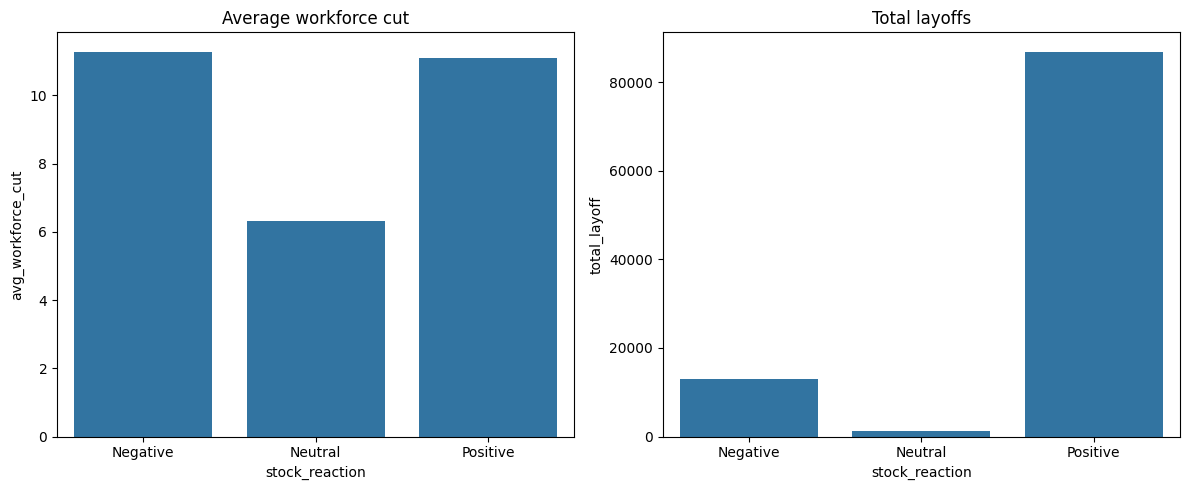

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

sns.barplot(
    data=stock_impact,
    x='stock_reaction', y='avg_workforce_cut', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=stock_impact,
    x='stock_reaction', y='total_layoff', ax=axes[1]
)
axes[1].set_title('Total layoffs')

plt.tight_layout()
plt.show()

5 . Are layoffs increasing or decreasing over time in 2026?

In [ ]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])
df["layoff_month_num"]  = df["layoff_date"].dt.month
df["layoff_month_name"] = df["layoff_date"].dt.strftime("%b")
increse_layoff = df.groupby(['layoff_month_num','layoff_month_name']).agg(
    total_job_cuts = ('jobs_cut' , 'sum'),
    avg_workforce = ('pct_workforce_cut' , 'mean')
)
increse_layoff.sort_values('layoff_month_num')

,,total_job_cuts,avg_workforce
layoff_month_num,layoff_month_name,,
1,Jan,32800,6.000000
2,Feb,46588,12.210000
3,Mar,21758,15.685714


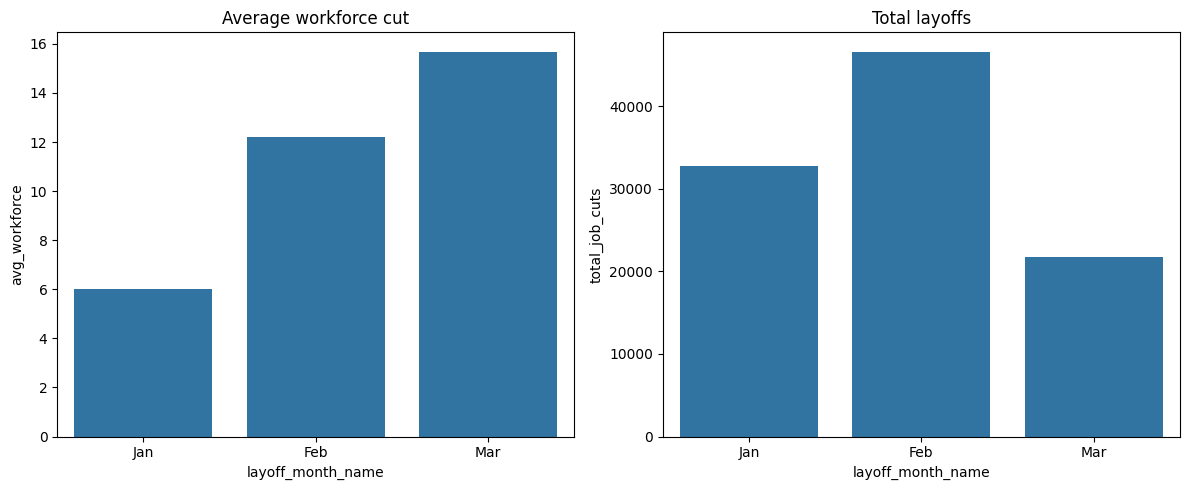

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

sns.barplot(
    data=increse_layoff,
    x='layoff_month_name', y='avg_workforce', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=increse_layoff,
    x='layoff_month_name', y='total_job_cuts', ax=axes[1]
)
axes[1].set_title('Total layoffs')

plt.tight_layout()
plt.show()

6 . Which regions are most affected by layoffs?

In [56]:
regions_layoff = df.groupby('region').agg(
    total_layoff = ('jobs_cut' , 'sum'),
    avg_workforce = ('pct_workforce_cut' , 'mean')
)
regions_layoff

,total_layoff,avg_workforce
region,,
Asia-Pacific,4600,16.666667
Europe,11500,6.900000
North America,85046,10.868421


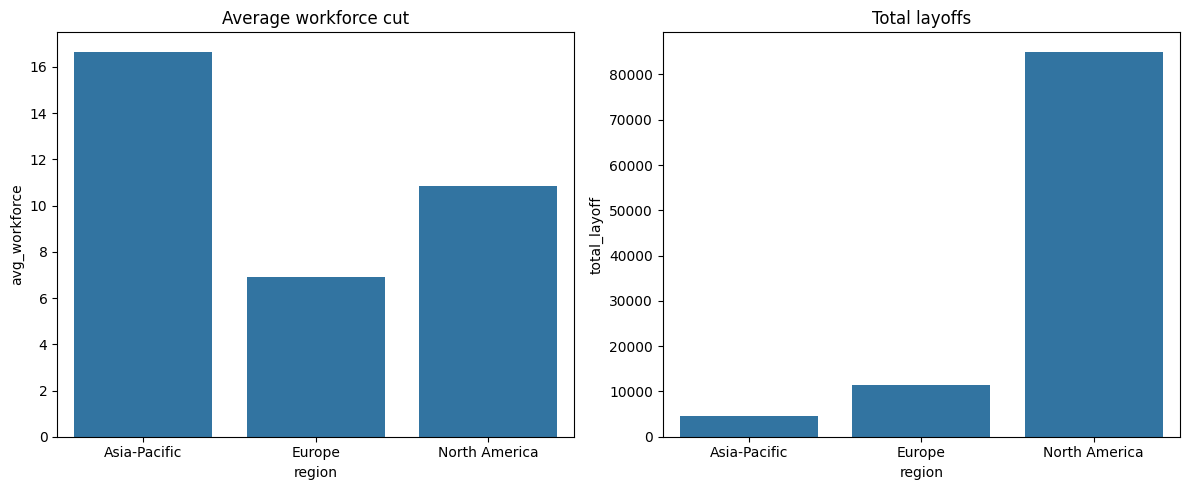

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

sns.barplot(
    data=regions_layoff,
    x='region', y='avg_workforce', ax=axes[0]
)
axes[0].set_title('Average workforce cut')

sns.barplot(
    data=regions_layoff,
    x='region', y='total_layoff', ax=axes[1]
)
axes[1].set_title('Total layoffs')

plt.tight_layout()
plt.show()

7. What are the most common reasons behind layoffs?